In [2]:
import pandas as pd
data=pd.read_csv(r"C:\Users\Shiva kumar\OneDrive\Desktop\DATASETS\train.csv")
data.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [3]:
data.shape

(891, 12)

In [4]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [5]:
data.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [6]:
#Handling missing values
data['Age']=data["Age"].fillna(data['Age'].median())

In [7]:
data['Embarked'] = data['Embarked'].fillna(data['Embarked'].mode()[0])

In [8]:
data = data.drop(columns=['Cabin'])

In [9]:
data= data.drop(columns=['PassengerId', 'Name', 'Ticket'])

In [10]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 8 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Survived  891 non-null    int64  
 1   Pclass    891 non-null    int64  
 2   Sex       891 non-null    object 
 3   Age       891 non-null    float64
 4   SibSp     891 non-null    int64  
 5   Parch     891 non-null    int64  
 6   Fare      891 non-null    float64
 7   Embarked  891 non-null    object 
dtypes: float64(2), int64(4), object(2)
memory usage: 55.8+ KB


In [11]:
data.isnull().sum()

Survived    0
Pclass      0
Sex         0
Age         0
SibSp       0
Parch       0
Fare        0
Embarked    0
dtype: int64

In [12]:
#Encoding categorical variables 
data['Sex']=data['Sex'].map({'male':0,'female':1})

In [13]:
data = pd.get_dummies(data, columns=['Embarked'], drop_first=True)

In [14]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Survived    891 non-null    int64  
 1   Pclass      891 non-null    int64  
 2   Sex         891 non-null    int64  
 3   Age         891 non-null    float64
 4   SibSp       891 non-null    int64  
 5   Parch       891 non-null    int64  
 6   Fare        891 non-null    float64
 7   Embarked_Q  891 non-null    bool   
 8   Embarked_S  891 non-null    bool   
dtypes: bool(2), float64(2), int64(5)
memory usage: 50.6 KB


In [15]:
#Preparing features and 
X=data.drop('Survived',axis=1)
X=X.astype(int)
y=data['Survived']

In [16]:
print(X.shape)
print(y.shape)

(891, 8)
(891,)


In [17]:
X.head()

,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked_Q,Embarked_S
0,3,0,22,1,0,7,0,1
1,1,1,38,1,0,71,0,0
2,3,1,26,0,0,7,0,1
3,1,1,35,1,0,53,0,1
4,3,0,35,0,0,8,0,1


In [18]:
X.dtypes

Pclass        int64
Sex           int64
Age           int64
SibSp         int64
Parch         int64
Fare          int64
Embarked_Q    int64
Embarked_S    int64
dtype: object

In [19]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

In [20]:
print(X_train.shape)

(712, 8)


In [21]:
print(X_test.shape)

(179, 8)


In [28]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC

models={
    "Logistic Regression":LogisticRegression(max_iter=100000),
    "Decision Tree Classifier":DecisionTreeClassifier(),
    "Random Forest":RandomForestClassifier(n_estimators=100),
    "KNN":KNeighborsClassifier(),
    "SVM":SVC()
}

In [29]:
for name,model in models.items():
    model.fit(X_train,y_train)
    print(f"{name} trained successfully")


Logistic Regression trained successfully
Decision Tree Classifier trained successfully
Random Forest trained successfully
KNN trained successfully
SVM trained successfully


In [30]:
results=[]
from sklearn.metrics import accuracy_score
for name,model in models.items():
    y_pred=model.predict(X_test)
    acc=accuracy_score(y_test,y_pred)
    results.append({
    "Model":name,
    "Accuracy":acc})

In [31]:
comparision_data=pd.DataFrame(results)

In [33]:
comparision_data

,Model,Accuracy
0,Logistic Regression,0.810056
1,Decision Tree Classifier,0.793296
2,Random Forest,0.798883
3,KNN,0.715084
4,SVM,0.653631


In [34]:
comparision_data=comparision_data.sort_values(by="Accuracy",ascending=False)

In [35]:
comparision_data

,Model,Accuracy
0,Logistic Regression,0.810056
2,Random Forest,0.798883
1,Decision Tree Classifier,0.793296
3,KNN,0.715084
4,SVM,0.653631


In [37]:
from sklearn.metrics import accuracy_score,precision_score,recall_score,f1_score

results=[]

for name,model in models.items():
    y_pred=model.predict(X_test)

    accuracy=accuracy_score(y_test,y_pred)
    precision=precision_score(y_test,y_pred)
    recall=recall_score(y_test,y_pred)
    f1=f1_score(y_test,y_pred)

    results.append({
    "Accuracy":accuracy,
    "Precision":precision,
    "recall":recall,
    "f1":f1})

In [39]:
comparision=pd.DataFrame(results)
comparision=comparision.sort_values(by="Accuracy",ascending=False)
comparision

,Accuracy,Precision,recall,f1
0,0.810056,0.785714,0.743243,0.763889
2,0.798883,0.771429,0.729730,0.750000
1,0.793296,0.753425,0.743243,0.748299
3,0.715084,0.716981,0.513514,0.598425
4,0.653631,0.750000,0.243243,0.367347


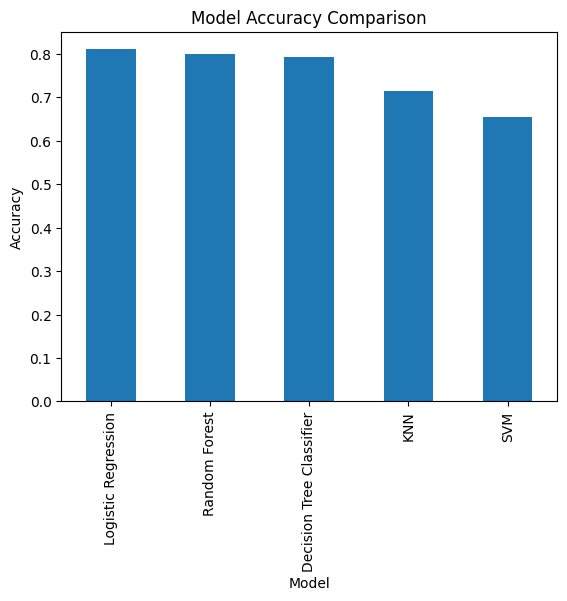

In [44]:
import matplotlib.pyplot as plt

comparision_data.set_index("Model")["Accuracy"].plot(kind="bar")

plt.title("Model Accuracy Comparison")
plt.ylabel("Accuracy")
plt.show()

In [51]:
#Adding feature scalling
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()
X_train=scaler.fit_transform(X_train)
X_test=scaler.transform(X_test)

In [52]:
for name,model in models.items():
    model.fit(X_train,y_train)
    

In [53]:
results=[]
from sklearn.metrics import accuracy_score
for name,model in models.items():
    y_pred=model.predict(X_test)
    acc=accuracy_score(y_test,y_pred)
    results.append({
    "Model":name,
    "Accuracy":acc})

In [54]:
comparison=pd.DataFrame(results)
comparison

,Model,Accuracy
0,Logistic Regression,0.810056
1,Decision Tree Classifier,0.804469
2,Random Forest,0.815642
3,KNN,0.804469
4,SVM,0.821229


In [55]:
from sklearn.model_selection import cross_val_score

In [56]:
results = []

for name, model in models.items():

    scores = cross_val_score(model, X, y, cv=5)

    results.append({
        "Model": name,
        "Cross Val Accuracy": scores.mean()
    })

In [57]:
comparison_df = pd.DataFrame(results)

comparison_df = comparison_df.sort_values(
    by="Cross Val Accuracy",
    ascending=False
)

comparison_df

,Model,Cross Val Accuracy
2,Random Forest,0.812598
1,Decision Tree Classifier,0.792380
0,Logistic Regression,0.790126
3,KNN,0.702643
4,SVM,0.674616


In [58]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier

param_grid = {
    "n_estimators": [100, 200, 300],
    "max_depth": [None, 5, 10],
    "min_samples_split": [2, 5, 10]
}

rf = RandomForestClassifier()

grid = GridSearchCV(
    rf,
    param_grid,
    cv=5,
    scoring="accuracy"
)

grid.fit(X_train, y_train)

print("Best Parameters:", grid.best_params_)
print("Best Accuracy:", grid.best_score_)

Best Parameters: {'max_depth': 5, 'min_samples_split': 5, 'n_estimators': 200}
Best Accuracy: 0.8300600807643062


In [59]:
import matplotlib.pyplot as plt

rf_best = grid.best_estimator_

importances = rf_best.feature_importances_

features = X.columns

importance_df = pd.DataFrame({
    "Feature": features,
    "Importance": importances
})

importance_df = importance_df.sort_values(by="Importance", ascending=False)

print(importance_df)

      Feature  Importance
1         Sex    0.440968
5        Fare    0.178823
0      Pclass    0.141020
2         Age    0.110300
3       SibSp    0.050415
4       Parch    0.040423
7  Embarked_S    0.029006
6  Embarked_Q    0.009045
